# Markov-Chain Monte-Carlo Single Simulation Case
---
Uses the MC-dropout emulator to infer the parameters of a single simulation using Markov-Chain Monte-Carlo.

Produces four figures:
1. Corner Plot
2. Posterior $D_\ell$ Spectrum
3. Posterior $D_\ell$ Spectrum with Residuals
4. Trace Plot


More information about the package can be found here: [Documentation](https://robertxpearce.github.io/reionization-emulator/)

## Imports

In [1]:
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
import emcee
import corner

from reionemu import (
    load_training_arrays,
    MCDropoutEmulator,
    Normalizer,
    predict_mc,
)

## Paths, Configs, and Constants

In [2]:
# Paths
from config import H5_PATH, MODEL_PATH, NORM_PATH, FIG_DIR, EXPERIMENT_NAME, make_dirs
from config import HELDOUT_INDICES_PATH, MCMC_SINGLE_PATH

# Constants
from config import SEED, PARAM_BOUNDS, param_order, param_labels, device, N_MC_EVAL
from config import N_DIM, N_WALKERS, N_STEPS, DISCARD, THIN

make_dirs()

## Seeding

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python:\t\t{sys.version.split()[0]}")
print("-" * 30)
print(f"NumPy:\t\t{np.__version__}")
print(f"PyTorch:\t{torch.__version__}")
print(f"emcee:\t\t{emcee.__version__}")
print(f"corner:\t\t{corner.__version__}")
print("-" * 30)
print(f"Global Seed:\t{SEED}")

Python:		3.13.1
------------------------------
NumPy:		2.4.3
PyTorch:	2.10.0
emcee:		3.1.6
corner:		2.2.3
------------------------------
Global Seed:	42


## Load Trained Model

In [4]:
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

model = MCDropoutEmulator(**ckpt["model_config"])
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

norms = {
    "X": Normalizer(
        mean=np.load(NORM_PATH / "X_mean.npy"),
        std=np.load(NORM_PATH / "X_std.npy"),
    ),
    "Y": None,
}

print(f"Model:\n{MODEL_PATH}")
print(f"Architecture:\t{ckpt['model_config']}")

Model:
/Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/model.pt
Architecture:	{'input_dim': 4, 'output_dim': 5, 'hidden_dim': 20, 'num_hidden_layers': 2, 'activation': 'relu', 'dropout_rate': 0.1}


# Parameter Inference - Markov-Chain Monte Carlo
---

## Simulation Selection from Held-Out Set

- The MC-dropout emulator cannot reliably extrapolate outside the parameterspace. Therefore, the optimal sample should be near the middle.
- To find the sample closest to the middle, we apply a transformation so the parameters are measured on a common scale
$$ u = \frac{(x -lo)}{(hi - lo)}$$
Then, we measure the distance each parameter is from the center of their bound:
$$d = \sqrt((u_1 - 0.5)^2 + (u_2 - 0.5)^2 + (u_3 - 0.5)^2 + (u_4 - 0.5)^2)$$

In [5]:
X, Y, ell = load_training_arrays(H5_PATH)

heldout_indices = np.load(HELDOUT_INDICES_PATH)

X_heldout = X[heldout_indices]
Y_heldout = Y[heldout_indices]

u = (X_heldout - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])
dist = np.linalg.norm(u - 0.5, axis=1)

central_order = np.argsort(dist)
smallest_dist = central_order[0]

print("Simulation with the Smallest Distance to the Center")
print(f"Test-Set Index: {smallest_dist} \t Global Dataset Index: {heldout_indices[smallest_dist]}")
print()
print("Top 5 Simulations with Smallest Distance to the Center")
for pos in central_order[:5]:
    print(f"\tTest-Set Index: {pos} \t Global Dataset Index: {heldout_indices[pos]} \n\t\tDist {dist[pos]:.3f} \t Params: {X_heldout[pos]}")

Simulation with the Smallest Distance to the Center
Test-Set Index: 37 	 Global Dataset Index: 106

Top 5 Simulations with Smallest Distance to the Center
	Test-Set Index: 37 	 Global Dataset Index: 106 
		Dist 0.174 	 Params: [7.7922134  0.47120032 1.299202   0.47073376]
	Test-Set Index: 11 	 Global Dataset Index: 32 
		Dist 0.197 	 Params: [7.895161   0.38562214 0.9680844  0.36761492]
	Test-Set Index: 30 	 Global Dataset Index: 450 
		Dist 0.208 	 Params: [8.279356   0.54046345 1.2756785  0.39021048]
	Test-Set Index: 0 	 Global Dataset Index: 560 
		Dist 0.226 	 Params: [8.035813  0.4903779 0.6846715 0.5314246]
	Test-Set Index: 90 	 Global Dataset Index: 111 
		Dist 0.238 	 Params: [7.940788   0.6186654  1.3747473  0.40292513]


## Likelihood Functions

In [6]:
def log_prior(theta):
    theta = np.asarray(theta)

    if np.any(theta < PARAM_BOUNDS[:, 0]) or np.any(theta > PARAM_BOUNDS[:, 1]):
        return -np.inf

    return 0.0


def predict_emulator(theta):
    theta = np.array(theta, dtype=np.float32)

    pred_dl, pred_std, _, _ = predict_mc(
        theta,
        model,
        norms["X"].mean,
        norms["X"].std,
        normalize_X=True,
        n_mc_samples=N_MC_EVAL,
        device=device,
    )

    return pred_dl, pred_std


def log_likelihood(theta, observed_dl, sigma_obs):
    model_dl, emulator_std = predict_emulator(theta)

    sigma_total = np.sqrt(sigma_obs**2 + emulator_std**2)

    residual = observed_dl - model_dl

    chi2 = np.sum((residual / sigma_total) ** 2)
    log_det = np.sum(np.log(2.0 * np.pi * sigma_total**2))

    return -0.5 * (chi2 + log_det)


def log_probability(theta, observed_dl, sigma_obs):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, observed_dl, sigma_obs)

## Mock Observation and Chain

In [7]:
%%time

TEST_SET_IDX = smallest_dist

true_params = X_heldout[TEST_SET_IDX]
observed_dl = np.exp(Y_heldout[TEST_SET_IDX])
sigma_obs = 0.10 * observed_dl

# MCMC setup
ndim = N_DIM
nwalkers = N_WALKERS
nsteps = N_STEPS

np.random.seed(SEED)
torch.manual_seed(SEED)

initial_pos = true_params + 1e-2 * np.random.randn(nwalkers, ndim)

for j, (low, high) in enumerate(PARAM_BOUNDS):
    initial_pos[:, j] = np.clip(initial_pos[:, j], low, high)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(observed_dl, sigma_obs),
)

sampler.run_mcmc(initial_pos, nsteps, progress=True)

chain = sampler.get_chain()
log_prob = sampler.get_log_prob()
acceptance = sampler.acceptance_fraction

print(f"Chain Shape: {chain.shape} (steps, walkers, ndim)")
print(f"Mean Acceptance Fraction: {np.mean(acceptance):.3f}")

100%|██████████| 30000/30000 [37:29<00:00, 13.34it/s]

Chain Shape: (30000, 32, 4) (steps, walkers, ndim)
Mean Acceptance Fraction: 0.426
CPU times: user 37min 13s, sys: 12.6 s, total: 37min 26s
Wall time: 37min 29s


## Likelihood Noise Check

In [8]:
n_repeat = 200
logp_repeat = np.array([
    log_probability(true_params, observed_dl, sigma_obs) for _ in range(n_repeat)
])

print(f"Log-Probability at Fixed Theta Over {n_repeat} Evaluations:")
print(f"\tmean\t= {logp_repeat.mean():.3f}")
print(f"\tstd\t\t= {logp_repeat.std(ddof=1):.3f}")
print(f"\trange\t= [{logp_repeat.min():.3f}, {logp_repeat.max():.3f}]")

Log-Probability at Fixed Theta Over 200 Evaluations:
	mean	= 5.898
	std		= 0.057
	range	= [5.750, 6.049]


## Diagnose Chain

In [9]:
tau_autocorr = emcee.autocorr.integrated_time(chain, tol=0)
tau_max = float(np.max(tau_autocorr))
n_per_walker = chain.shape[0]

print("Autocorrelation Time Per Parameter:", tau_autocorr)
print(f"N / Tau = {n_per_walker / tau_max:.0f}")

# MCMC_DISCARD = int(5 * tau_max)
# MCMC_THIN = max(1, int(0.5 * tau_max))
MCMC_DISCARD = DISCARD
MCMC_THIN = THIN

samples = sampler.get_chain(discard=MCMC_DISCARD, thin=MCMC_THIN, flat=True)

print(f"Discard={MCMC_DISCARD}, Thin={MCMC_THIN}, Posterior Samples={samples.shape[0]}")
print(f"Chain: {chain.shape} | Samples: {samples.shape}")

Autocorrelation Time Per Parameter: [100.5189157   97.6453522  111.87855302 101.98058487]
N / Tau = 268
Discard=1000, Thin=100, Posterior Samples=9280
Chain: (30000, 32, 4) | Samples: (9280, 4)


## Metrics

In [10]:
print(f"True Parameters: {true_params}")
print()
print("Posterior Median with 68% Credible Interval:")
for i, label in enumerate(param_order):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    print(f"\t{label}: {q50:.3f} + {q84 - q50:.3f} - {q50 - q16:.3f}")

print()
print("Mean Acceptance Fraction:\t", np.mean(acceptance))
print("Acceptance Fractions:\t", acceptance)

True Parameters: [7.7922134  0.47120032 1.299202   0.47073376]

Posterior Median with 68% Credible Interval:
	zmean_zre: 7.775 + 0.744 - 0.549
	alpha_zre: 0.389 + 0.287 - 0.198
	kb_zre: 1.212 + 0.547 - 0.645
	b0_zre: 0.486 + 0.097 - 0.076

Mean Acceptance Fraction:	 0.426409375
Acceptance Fractions:	 [0.4294     0.4268     0.4248     0.42553333 0.42266667 0.42526667
 0.4231     0.42236667 0.4254     0.4276     0.42276667 0.4279
 0.42296667 0.43563333 0.4223     0.43266667 0.42466667 0.4292
 0.42123333 0.4231     0.42886667 0.42676667 0.425      0.42913333
 0.42716667 0.43066667 0.43053333 0.4142     0.43383333 0.42833333
 0.42873333 0.4265    ]


## Corner Plot

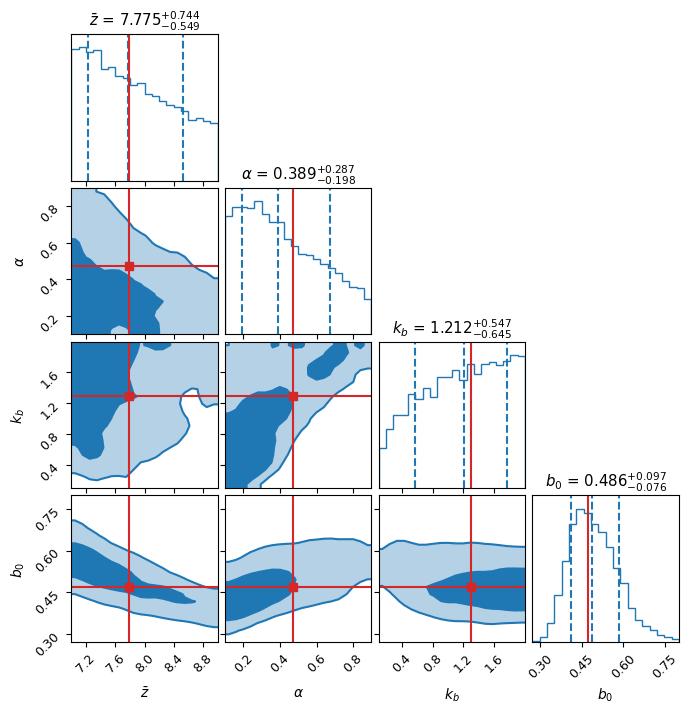

In [11]:
samples_for_corner = samples

fig = plt.figure(figsize=(7.1, 7.1))

fig = corner.corner(
    samples_for_corner,
    fig=fig,
    labels=param_labels,
    truths=true_params,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=False,
    fill_contours=True,
    smooth=1.0,

    levels=(1 - np.exp(-0.5), 1 - np.exp(-2.0)), 

    truth_color="tab:red",               
    color="tab:blue",                    
    label_kwargs={"fontsize": 10},
)

plt.savefig(FIG_DIR / f"emulator_based_MCMC_posterior_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Posterior $D_\ell$ Spectrum

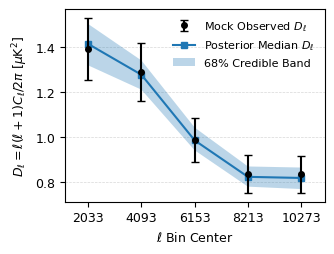

In [12]:
rng = np.random.default_rng(SEED)
n_draws = 200
draw_indices = rng.choice(len(samples), size=n_draws, replace=False)
theta_draws = samples[draw_indices]

posterior_preds = []
for theta in theta_draws:
    draw_dl, _draw_std = predict_emulator(theta)
    posterior_preds.append(draw_dl)

posterior_preds = np.asarray(posterior_preds)

pred_16, pred_50, pred_84 = np.percentile(posterior_preds, [16, 50, 84], axis=0)


fig, ax = plt.subplots()

band = ax.fill_between(ell, pred_16, pred_84, color="tab:blue", alpha=0.3, edgecolor="none", label=r"68% Credible Band", zorder=2)
median, = ax.plot(ell, pred_50, marker="s", markersize=4, color="tab:blue", label=r"Posterior Median $D_\ell$", zorder=3)
obs = ax.errorbar(ell, observed_dl, yerr=sigma_obs, marker="o", color="black", markersize=4, capsize=3, linestyle="none", label=r"Mock Observed $D_\ell$", zorder=4)

ax.set_xlabel(r"$\ell$ Bin Center")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$ [$\mu \mathrm{K}^2$]")

ax.set_xticks(ell)
ax.set_xticklabels([f"{e:.0f}" for e in ell])
ax.set_xlim(ell[0] - 900, ell[-1] + 900)

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

ax.legend([obs, median, band], [obs.get_label(), median.get_label(), band.get_label()], frameon=False, fontsize=8, loc="upper right")

fig.savefig(FIG_DIR / f"posterior_spectrum_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Posterior $D_\ell$ Spectrum with Residuals

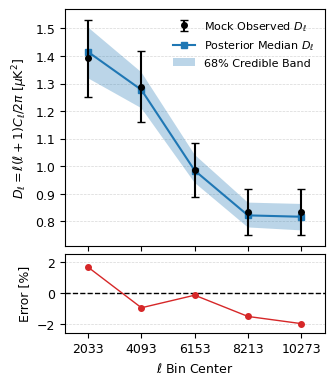

In [13]:
pct_error = 100.0 * (pred_50 - observed_dl) / observed_dl

fig, (ax_main, ax_res) = plt.subplots(nrows=2, ncols=1, figsize=(3.35, 4.2), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

band = ax_main.fill_between(ell, pred_16, pred_84, color="tab:blue", alpha=0.3, edgecolor="none", label=r"68% Credible Band", zorder=2)
median, = ax_main.plot(ell, pred_50, marker="s", markersize=4, color="tab:blue", label=r"Posterior Median $D_\ell$", zorder=3)
obs = ax_main.errorbar(ell, observed_dl, yerr=sigma_obs, marker="o", color="black", markersize=4, capsize=3, linestyle="none", label=r"Mock Observed $D_\ell$", zorder=4)

ax_main.set_ylabel(r"$D_\ell = \ell(\ell+1)C_\ell/2\pi$ [$\mu \mathrm{K}^2$]")
ax_main.set_axisbelow(True)
ax_main.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax_main.legend([obs, median, band], [obs.get_label(), median.get_label(), band.get_label()], frameon=False, fontsize=8, loc="upper right")

ax_res.axhline(0.0, color="black", linestyle="--", linewidth=1.0, zorder=1)
ax_res.plot(ell, pct_error, marker="o", markersize=4, color="tab:red", linewidth=1.0, zorder=2)

ax_res.set_xlabel(r"$\ell$ Bin Center")
ax_res.set_ylabel("Error [%]")
ax_res.set_axisbelow(True)
ax_res.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

lim = max(1.3 * np.max(np.abs(pct_error)), 1.0)
ax_res.set_ylim(-lim, lim)

ax_res.set_xticks(ell)
ax_res.set_xticklabels([f"{e:.0f}" for e in ell])
ax_res.set_xlim(ell[0] - 900, ell[-1] + 900)

fig.subplots_adjust(hspace=0.05)

fig.savefig(FIG_DIR / f"posterior_spectrum_with_residuals_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Trace Plot

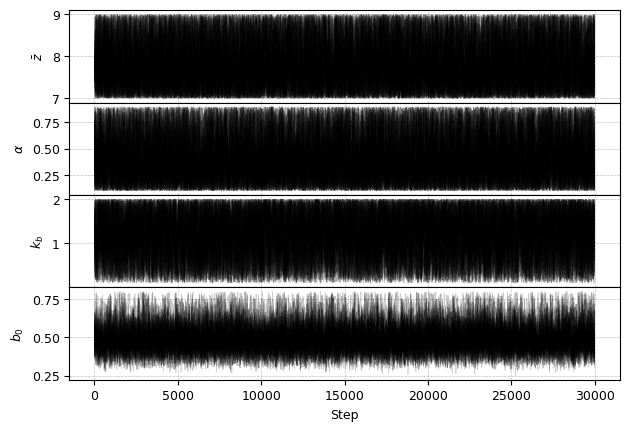

In [14]:
fig, axes = plt.subplots(ndim, figsize=(7.1, 4.8), sharex=True)

if ndim == 1:
    axes = [axes]

for i in range(ndim):
    axes[i].plot(chain[:, :, i], color="black", alpha=0.2, linewidth=0.5)
    
    axes[i].set_ylabel(param_labels[i])
    
    axes[i].set_axisbelow(True)
    axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.8)

axes[-1].set_xlabel("Step")

plt.subplots_adjust(hspace=0.0)

plt.savefig(FIG_DIR / f"trace_plot_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Save Chain

In [15]:
np.savez(
    MCMC_SINGLE_PATH,
    chain=chain,
    log_prob=log_prob,
    acceptance=acceptance,
    samples=samples,
    true_params=true_params,
    observed_dl=observed_dl,
    sigma_obs=sigma_obs,
    test_set_idx=TEST_SET_IDX,
    heldout_index=heldout_indices[TEST_SET_IDX],
    discard=MCMC_DISCARD,
    thin=MCMC_THIN,
)

print(f"Chain saved to:\n{MCMC_SINGLE_PATH}")

Chain saved to:
/Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/mcmc_single.npz
